# CNN photo-z → spec-z avec DANN sur COSMOS

# Fait par Maximiliano RUIZ


## 1. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, gc, glob, copy, itertools
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.optimize import minimize_scalar

appareil = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Appareil : {appareil}")
if appareil.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
torch.backends.cudnn.benchmark = True

def statut_ram(etiquette=""):
    r = psutil.virtual_memory()
    print(f"[RAM {etiquette}] {r.used/1e9:.2f} Go / {r.total/1e9:.2f} Go ({r.percent:.1f}%)")

statut_ram("démarrage")

Appareil : cuda
GPU      : Tesla T4
[RAM démarrage] 1.70 Go / 13.61 Go (14.7%)


## 2. Chargement séparé : photo (source) et spec (cible)

**Vocabulaire DANN** : photo = domaine **source** (labels disponibles), spec = domaine **cible** (labels masqués pendant l'entraînement, révélés au test).

In [4]:
dossier = "/content/drive/MyDrive/redshift"
os.chdir(dossier)
fichiers_npz = glob.glob("*.npz")

fichiers_photo = [f for f in fichiers_npz if "COSMOS" in f and "photo" in f.lower()]
fichiers_spec  = [f for f in fichiers_npz if "COSMOS" in f and "spec"  in f.lower()]
print(f"Fichiers photo (source) : {len(fichiers_photo)}")
print(f"Fichiers spec  (cible)  : {len(fichiers_spec)}")
assert len(fichiers_photo) > 0, 'Aucun fichier photo trouvé'
assert len(fichiers_spec)  > 0, 'Aucun fichier spec trouvé'

Fichiers photo (source) : 2
Fichiers spec  (cible)  : 2


In [5]:
def charger_subset(liste_fichiers, nom_colonne_z):
    liste_info, liste_cube = [], []
    for f in liste_fichiers:
        try:
            d = np.load(f, allow_pickle=True)
            liste_info.append(d['info']); liste_cube.append(d['cube'])
            print(f"  Chargé : {f}  (cube {d['cube'].shape})")
        except Exception as e:
            print(f"  Erreur : {f} — {e}")
    enregs = []
    for tab in liste_info:
        for r in tab:
            enregs.append({nom: r[nom] for nom in tab.dtype.names})
    df   = pd.DataFrame(enregs)
    cube = np.concatenate(liste_cube, axis=0)
    if nom_colonne_z in df.columns:
        df = df.rename(columns={nom_colonne_z: "redshift"})
    return df, cube

print("=== Chargement PHOTO (source) ===")
df_photo, cube_photo = charger_subset(fichiers_photo, "ZPHOT")
print(f"PHOTO : {len(df_photo)} galaxies, cube {cube_photo.shape}")

print("\n=== Chargement SPEC (cible) ===")
df_spec, cube_spec = charger_subset(fichiers_spec, "ZSPEC")
print(f"SPEC  : {len(df_spec)} galaxies, cube {cube_spec.shape}")
statut_ram("après chargement")

=== Chargement PHOTO (source) ===
  Chargé : COSMOS_v11_uijk_0213_photo_UD.npz  (cube (443, 64, 64, 9))
  Chargé : COSMOS_v11_uijk_0001_photo_D.npz  (cube (12054, 64, 64, 9))
PHOTO : 12497 galaxies, cube (12497, 64, 64, 9)

=== Chargement SPEC (cible) ===
  Chargé : COSMOS_v11_uijk_0020_spec_D.npz  (cube (15, 64, 64, 9))
  Chargé : COSMOS_v11_uijk_0073_spec_UD.npz  (cube (12, 64, 64, 9))
SPEC  : 27 galaxies, cube (27, 64, 64, 9)
[RAM après chargement] 3.68 Go / 13.61 Go (29.5%)


## 3. Nettoyage minimal

In [6]:
def nettoyer(df, cube):
    masque  = df['redshift'].notna()
    masque &= df['redshift'].between(0, 10)
    return df[masque].copy().reset_index(drop=True), cube[masque.values].copy()

df_photo, cube_photo = nettoyer(df_photo, cube_photo)
df_spec,  cube_spec  = nettoyer(df_spec,  cube_spec)
print(f"PHOTO : {len(df_photo)} galaxies   SPEC : {len(df_spec)} galaxies")
gc.collect(); statut_ram("après nettoyage")

PHOTO : 12497 galaxies   SPEC : 27 galaxies
[RAM après nettoyage] 3.68 Go / 13.61 Go (29.5%)


## 4. Prétraitement avec imputation + flag

In [ ]:
magnitudes_base = ['u', 'g', 'r', 'i', 'z', 'y']
nb_bandes = len(magnitudes_base)

img_photo = np.arcsinh(cube_photo.astype(np.float32))
img_spec  = np.arcsinh(cube_spec .astype(np.float32))
img_photo = np.nan_to_num(img_photo, nan=0.0, posinf=0.0, neginf=0.0)
img_spec  = np.nan_to_num(img_spec,  nan=0.0, posinf=0.0, neginf=0.0)
del cube_photo, cube_spec; gc.collect()

mag_photo_brut = df_photo[magnitudes_base].values.astype(np.float32)
mag_spec_brut  = df_spec [magnitudes_base].values.astype(np.float32)
mag_photo_brut[mag_photo_brut < -90] = np.nan
mag_spec_brut [mag_spec_brut  < -90] = np.nan

flag_photo = np.isnan(mag_photo_brut).astype(np.float32)
flag_spec  = np.isnan(mag_spec_brut ).astype(np.float32)

mediane_par_bande = np.nanmedian(mag_photo_brut, axis=0)
mag_photo = np.where(np.isnan(mag_photo_brut), mediane_par_bande, mag_photo_brut).astype(np.float32)
mag_spec  = np.where(np.isnan(mag_spec_brut ), mediane_par_bande, mag_spec_brut ).astype(np.float32)

mag_photo = np.concatenate([mag_photo, flag_photo], axis=1)
mag_spec  = np.concatenate([mag_spec,  flag_spec ], axis=1)

y_photo = df_photo['redshift'].values.astype(np.float32)
y_spec  = df_spec ['redshift'].values.astype(np.float32)
print(f"Shape mags : photo={mag_photo.shape}, spec={mag_spec.shape}")

Shape mags : photo=(12497, 12), spec=(27, 12)


In [ ]:
nb_bins = 150
z_min   = min(y_photo.min(), y_spec.min())
z_max   = max(y_photo.max(), y_spec.max())
bords_bins   = np.linspace(z_min, z_max, nb_bins + 1).astype(np.float32)
centres_bins = ((bords_bins[:-1] + bords_bins[1:]) / 2).astype(np.float32)

def binariser(y, bords):
    yb = np.clip(np.searchsorted(bords, y, side='right') - 1, 0, len(bords) - 2)
    return yb.astype(np.int64)

yb_photo = binariser(y_photo, bords_bins)
yb_spec  = binariser(y_spec,  bords_bins)
yb_photo_grossier = binariser(y_photo, np.linspace(z_min, z_max, 21))
print(f"Range z combiné : [{z_min:.3f}, {z_max:.3f}]")

Range z combiné : [0.000, 5.965]


## 5. Split

Le test/cible **reste l'ensemble spec entier**. C'est un choix transductif : ces 27 galaxies seront vues sans label pendant l'entraînement DANN, puis utilisées avec leur label pour l'évaluation finale.

In [ ]:
(images_train, images_val,
 mags_train,   mags_val,
 yb_train,     yb_val,
 yo_train,     yo_val) = train_test_split(
    img_photo, mag_photo, yb_photo, y_photo,
    test_size=0.15, random_state=42, stratify=yb_photo_grossier)

# Le subset spec sert à la fois de cible DANN (sans label) et de test (avec label)
images_cible = img_spec.copy()    # pour l'entraînement DANN, sans label
mags_cible   = mag_spec.copy()
images_test  = img_spec           # pour l'évaluation, avec label
mags_test    = mag_spec
yb_test      = yb_spec
yo_test      = y_spec

del img_photo, mag_photo, yb_photo, y_photo, yb_photo_grossier
del img_spec, mag_spec, yb_spec, y_spec
gc.collect()
print(f"Source (photo) : train {len(images_train)} / val {len(images_val)}")
print(f"Cible  (spec)  : {len(images_cible)} galaxies (DANN sans labels + test avec labels)")
statut_ram("après split")

Source (photo) : train 10622 / val 1875
Cible  (spec)  : 27 galaxies (DANN sans labels + test avec labels)
[RAM après split] 3.68 Go / 13.61 Go (29.3%)


## 6. Normalisation

In [ ]:
moyenne_bande = images_train.mean(axis=(0,1,2), keepdims=True)
ecart_bande   = images_train.std (axis=(0,1,2), keepdims=True) + 1e-6
images_train  = ((images_train - moyenne_bande) / ecart_bande).astype(np.float16)
images_val    = ((images_val   - moyenne_bande) / ecart_bande).astype(np.float16)
images_cible  = ((images_cible - moyenne_bande) / ecart_bande).astype(np.float16)
images_test   = ((images_test  - moyenne_bande) / ecart_bande).astype(np.float16)

moyenne_mag = mags_train[:, :nb_bandes].mean(axis=0, keepdims=True)
ecart_mag   = mags_train[:, :nb_bandes].std (axis=0, keepdims=True) + 1e-6
for arr in [mags_train, mags_val, mags_cible, mags_test]:
    arr[:, :nb_bandes] = (arr[:, :nb_bandes] - moyenne_mag) / ecart_mag

gc.collect(); statut_ram("après normalisation")

[RAM après normalisation] 2.76 Go / 13.61 Go (22.6%)


In [ ]:
SIGMA_DOUX = 2.0
def labels_doux(yb, nb_classes, sigma=2.0):
    bins  = np.arange(nb_classes, dtype=np.float32)[None, :]
    y_arr = yb.reshape(-1, 1).astype(np.float32)
    p     = np.exp(-0.5 * ((bins - y_arr) / sigma) ** 2)
    return (p / p.sum(axis=1, keepdims=True)).astype(np.float32)

labels_doux_train = labels_doux(yb_train, nb_bins, SIGMA_DOUX)
labels_doux_val   = labels_doux(yb_val,   nb_bins, SIGMA_DOUX)

## 7. Tenseurs + Datasets

In [ ]:
def to_img_tensor(arr):
    return torch.tensor(arr, dtype=torch.float16).permute(0,3,1,2).contiguous()

t_images_train = to_img_tensor(images_train)
t_images_val   = to_img_tensor(images_val)
t_images_cible = to_img_tensor(images_cible)
t_images_test  = to_img_tensor(images_test)

t_mags_train  = torch.tensor(mags_train,  dtype=torch.float32)
t_mags_val    = torch.tensor(mags_val,    dtype=torch.float32)
t_mags_cible  = torch.tensor(mags_cible,  dtype=torch.float32)
t_mags_test   = torch.tensor(mags_test,   dtype=torch.float32)
t_lab_train   = torch.tensor(labels_doux_train,  dtype=torch.float32)
t_lab_val     = torch.tensor(labels_doux_val,    dtype=torch.float32)
t_yb_train    = torch.tensor(yb_train,  dtype=torch.long)
t_yb_val      = torch.tensor(yb_val,    dtype=torch.long)
t_yb_test     = torch.tensor(yb_test,   dtype=torch.long)
t_yo_train    = torch.tensor(yo_train,  dtype=torch.float32)
t_yo_val      = torch.tensor(yo_val,    dtype=torch.float32)

del images_train, images_val, images_cible, images_test
del mags_train, mags_val, mags_cible, mags_test
del labels_doux_train, labels_doux_val
gc.collect(); statut_ram("après tenseurs")

[RAM après tenseurs] 2.80 Go / 13.61 Go (22.9%)


## 8. Dataset source (avec random masking) et Dataset cible

**Deux datasets distincts** :
- `DatasetSource` : photo, avec labels, avec random masking augmentation
- `DatasetCible`  : spec, **sans labels**, mêmes augmentations d'image

Le random masking reste activé sur la source pour briser la corrélation `flag=1 → haut-z`.

In [ ]:
class DatasetSource(Dataset):
    """Photo (source) : images, magnitudes, labels, avec augmentation."""
    def __init__(self, X_img, X_mag, y_doux, y_dur, y_flottant,
                 augmentation=True, val_imp_norm=None, prob_masque=0.15):
        self.X_img=X_img; self.X_mag=X_mag; self.y_doux=y_doux
        self.y_dur=y_dur; self.y_flottant=y_flottant
        self.augmentation=augmentation
        self.val_imp_norm=val_imp_norm
        self.prob_masque=prob_masque
        self.nb_bandes=6
    def __len__(self): return len(self.X_img)
    def __getitem__(self, idx):
        x_img = self.X_img[idx].float()
        x_mag = self.X_mag[idx].clone()
        y_d, y_h, y_f = self.y_doux[idx], self.y_dur[idx], self.y_flottant[idx]
        if self.augmentation:
            k = int(torch.randint(0, 4, (1,)).item())
            if k > 0:                      x_img = torch.rot90(x_img, k, dims=[1,2])
            if torch.rand(1).item() < 0.5: x_img = torch.flip(x_img, dims=[1])
            if torch.rand(1).item() < 0.5: x_img = torch.flip(x_img, dims=[2])
            if self.val_imp_norm is not None:
                m = torch.rand(self.nb_bandes) < self.prob_masque
                if m.any():
                    x_mag[:self.nb_bandes][m] = self.val_imp_norm[m]
                    x_mag[self.nb_bandes:][m] = 1.0
        return x_img, x_mag, y_d, y_h, y_f


class DatasetCible(Dataset):
    """Spec (cible) : images, magnitudes, PAS de labels — mêmes augmentations d'image."""
    def __init__(self, X_img, X_mag, augmentation=True):
        self.X_img=X_img; self.X_mag=X_mag
        self.augmentation=augmentation
    def __len__(self): return len(self.X_img)
    def __getitem__(self, idx):
        x_img = self.X_img[idx].float()
        x_mag = self.X_mag[idx]
        if self.augmentation:
            k = int(torch.randint(0, 4, (1,)).item())
            if k > 0:                      x_img = torch.rot90(x_img, k, dims=[1,2])
            if torch.rand(1).item() < 0.5: x_img = torch.flip(x_img, dims=[1])
            if torch.rand(1).item() < 0.5: x_img = torch.flip(x_img, dims=[2])
        return x_img, x_mag


# --- Pré-calcul valeurs imputées normalisées (idem version précédente) -------
val_imp_norm = torch.tensor(
    ((mediane_par_bande - moyenne_mag[0]) / ecart_mag[0]).astype(np.float32))

dataset_source_train = DatasetSource(
    t_images_train, t_mags_train, t_lab_train, t_yb_train, t_yo_train,
    augmentation=True, val_imp_norm=val_imp_norm, prob_masque=0.15)
dataset_source_val   = DatasetSource(
    t_images_val, t_mags_val, t_lab_val, t_yb_val, t_yo_val,
    augmentation=False)
dataset_cible        = DatasetCible(t_images_cible, t_mags_cible, augmentation=True)

# Batch_size cible petit (N=27 total). Le sampler shuffle à chaque epoch.
chargeur_source_train = DataLoader(dataset_source_train, batch_size=64, shuffle=True,
                                   num_workers=0, pin_memory=True)
chargeur_source_val   = DataLoader(dataset_source_val,   batch_size=64, shuffle=False,
                                   num_workers=0, pin_memory=True)
chargeur_cible        = DataLoader(dataset_cible, batch_size=16, shuffle=True,
                                   num_workers=0, pin_memory=True)
print(f"DataLoaders prêts.")
print(f"  source train : {len(chargeur_source_train)} batches × 64")
print(f"  source val   : {len(chargeur_source_val)} batches × 64")
print(f"  cible        : {len(chargeur_cible)} batches × 16  (cyclé pendant l'entraînement)")

DataLoaders prêts.
  source train : 166 batches × 64
  source val   : 30 batches × 64
  cible        : 2 batches × 16  (cyclé pendant l'entraînement)


## 9. Modèle avec DANN

### Composants

1. **Extracteur de features** : `couches_cnn` + `mlp_mag` + concaténation (inchangé)
2. **Têtes redshift** : `tete_cls` (150 logits) + `tete_reg` (1 scalaire) (inchangées)
3. **Tête de domaine** (nouveau) : `tete_domaine` (2 logits : photo vs spec)
4. **Gradient Reversal Layer** entre l'extracteur et la tête de domaine

### Mécanisme du GRL

Forward : identité (laisse passer les features inchangées).
Backward : multiplie le gradient par `−λ`.

Conséquence : pendant la rétro-propagation, le backbone est **poussé à produire des features que le classifieur de domaine ne peut PAS distinguer**. L'extracteur est donc forcé à apprendre une représentation invariante au domaine.

### Le schedule de λ (Ganin & Lempitsky 2015)

`λ(p) = 2/(1+exp(-10p)) - 1`, où `p` ∈ [0,1] est la progression de l'entraînement.

Démarre à 0 (DANN inactif) puis monte vers 1. Pourquoi : on laisse d'abord le réseau apprendre la tâche redshift sur la source, puis on l'embête progressivement avec l'alignement de domaine.

In [ ]:
class CoucheReversementGradient(torch.autograd.Function):
    """Forward identité, backward multiplie le gradient par -lambda."""
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None

def reverser_gradient(x, lambda_=1.0):
    return CoucheReversementGradient.apply(x, lambda_)


class ModeleRedshiftDANN(nn.Module):
    def __init__(self, nb_canaux, haut_img, larg_img, nb_mag, nb_classes):
        super().__init__()
        # Extracteur images
        self.couches_cnn = nn.Sequential(
            nn.Conv2d(nb_canaux, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.AvgPool2d(2,2), nn.Dropout(0.2),
            nn.Conv2d(32, 64, 3, padding=1),        nn.BatchNorm2d(64),  nn.ReLU(),
            nn.AvgPool2d(2,2), nn.Dropout(0.2),
            nn.Conv2d(64, 128, 3, padding=1),       nn.BatchNorm2d(128), nn.ReLU(),
            nn.AvgPool2d(2,2), nn.Dropout(0.2),
        )
        with torch.no_grad():
            t = self.couches_cnn(torch.randn(1, nb_canaux, haut_img, larg_img)).numel()
        # Extracteur magnitudes
        self.mlp_mag = nn.Sequential(nn.Linear(nb_mag, 64), nn.ReLU(),
                                     nn.Linear(64, 32),    nn.ReLU())
        self.dim_features = t + 32
        # Têtes redshift (inchangées)
        self.tete_cls = nn.Sequential(nn.Linear(self.dim_features, 256), nn.ReLU(),
                                      nn.Dropout(0.5), nn.Linear(256, nb_classes))
        self.tete_reg = nn.Sequential(nn.Linear(self.dim_features, 128), nn.ReLU(),
                                      nn.Dropout(0.3), nn.Linear(128, 1))
        # NOUVEAU : tête de classification de domaine
        self.tete_domaine = nn.Sequential(
            nn.Linear(self.dim_features, 64), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2))   # 2 classes : photo (0) ou spec (1)

    def extraire_features(self, img, mag):
        f_img = self.couches_cnn(img).reshape(img.size(0), -1)
        f_mag = self.mlp_mag(mag)
        return torch.cat([f_img, f_mag], dim=1)

    def forward(self, img, mag, lambda_dann=0.0):
        f = self.extraire_features(img, mag)
        logits_cls = self.tete_cls(f)
        logits_reg = self.tete_reg(f)
        # Gradient reversal AVANT la tête de domaine
        f_rev = reverser_gradient(f, lambda_dann)
        logits_dom = self.tete_domaine(f_rev)
        return logits_cls, logits_reg, logits_dom


nb_canaux = t_images_train.shape[1]
haut_img  = t_images_train.shape[2]
larg_img  = t_images_train.shape[3]
nb_mag    = t_mags_train.shape[1]

_m = ModeleRedshiftDANN(nb_canaux, haut_img, larg_img, nb_mag, nb_bins)
print(f"Paramètres entraînables : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
print(f"  dont tête domaine    : {sum(p.numel() for p in _m.tete_domaine.parameters()):,}")
del _m

Paramètres entraînables : 3,821,945
  dont tête domaine    : 526,530


## 10. Boucle d'entraînement DANN

À chaque pas :
1. Un batch source → forward → 3 outputs (cls, reg, dom)
2. Un batch cible → forward → 1 output utilisé (dom)
3. Loss totale : `L_redshift(source) + L_domaine(source) + L_domaine(cible)`
4. `λ` est calculé selon la progression dans l'entraînement

In [ ]:
def perte_ce_douce(logits, cibles_douces):
    return -(cibles_douces * torch.log_softmax(logits, dim=1)).sum(dim=1).mean()

def calcul_lambda_dann(epoch, total_epochs, batch_idx, total_batches):
    """Schedule Ganin & Lempitsky : sigmoïde de 0 à 1."""
    p = (epoch * total_batches + batch_idx) / (total_epochs * total_batches)
    return float(2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)

LAMBDA_REG  = 0.1
LAMBDA_DOM_MAX = 1.0   # multiplicateur global de la loss de domaine
utiliser_amp = (appareil.type == 'cuda')

def entrainer_un_modele_dann(graine=42, nb_epochs=200, patience=30, verbose=True):
    torch.manual_seed(graine); np.random.seed(graine)
    modele = ModeleRedshiftDANN(nb_canaux, haut_img, larg_img, nb_mag, nb_bins).to(appareil)
    opt    = optim.AdamW(modele.parameters(), lr=5e-4, weight_decay=1e-4)
    sched  = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=7)
    scaler = torch.amp.GradScaler('cuda', enabled=utiliser_amp)
    meilleure_val = float('inf'); compteur_patience = 0; meilleur_etat = None
    pt, pv, prt, prv, lam_log, acc_dom_log = [], [], [], [], [], []

    iter_cible = itertools.cycle(chargeur_cible)
    nb_batches_source = len(chargeur_source_train)

    for epoch in range(nb_epochs):
        modele.train()
        s_loss = s_ok = s_n = s_dom_ok = s_dom_n = 0

        for batch_idx, (x_img_s, x_mag_s, y_d, y_h, y_f) in enumerate(chargeur_source_train):
            # ----- Batch cible (cyclé) -----
            x_img_t, x_mag_t = next(iter_cible)

            x_img_s = x_img_s.to(appareil, non_blocking=True)
            x_mag_s = x_mag_s.to(appareil, non_blocking=True)
            y_d = y_d.to(appareil, non_blocking=True)
            y_h = y_h.to(appareil, non_blocking=True)
            y_f = y_f.to(appareil, non_blocking=True)
            x_img_t = x_img_t.to(appareil, non_blocking=True)
            x_mag_t = x_mag_t.to(appareil, non_blocking=True)

            # ----- λ courant -----
            lam = calcul_lambda_dann(epoch, nb_epochs, batch_idx, nb_batches_source)

            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=utiliser_amp):
                # Forward source
                logits_cls_s, logits_reg_s, logits_dom_s = modele(x_img_s, x_mag_s, lam)
                # Forward cible (on n'utilise que le logit de domaine)
                _, _, logits_dom_t = modele(x_img_t, x_mag_t, lam)

                # Loss redshift sur source uniquement
                loss_z = perte_ce_douce(logits_cls_s, y_d) + LAMBDA_REG * F.mse_loss(logits_reg_s.squeeze(), y_f)

                # Loss domaine : source = 0, cible = 1
                y_dom_s = torch.zeros(x_img_s.size(0), dtype=torch.long, device=appareil)
                y_dom_t = torch.ones (x_img_t.size(0), dtype=torch.long, device=appareil)
                loss_dom = F.cross_entropy(logits_dom_s, y_dom_s) + F.cross_entropy(logits_dom_t, y_dom_t)

                loss = loss_z + LAMBDA_DOM_MAX * loss_dom

            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()

            s_loss += loss.item()
            _, p_cls = torch.max(logits_cls_s, 1)
            s_ok += (p_cls == y_h).sum().item(); s_n += y_h.size(0)
            # Accuracy du classifieur de domaine (devrait tomber à 50% si DANN fonctionne)
            with torch.no_grad():
                p_dom = torch.cat([logits_dom_s.argmax(1), logits_dom_t.argmax(1)])
                y_dom_all = torch.cat([y_dom_s, y_dom_t])
                s_dom_ok += (p_dom == y_dom_all).sum().item(); s_dom_n += y_dom_all.size(0)

        ept, eprt = s_loss / nb_batches_source, s_ok / s_n
        acc_dom = s_dom_ok / s_dom_n
        lam_log.append(lam); acc_dom_log.append(acc_dom)

        # ----- Validation : uniquement sur source (val photo) -----
        modele.eval(); v_loss = v_ok = v_n = 0
        with torch.no_grad():
            for x_img, x_mag, y_d, y_h, y_f in chargeur_source_val:
                x_img=x_img.to(appareil,non_blocking=True); x_mag=x_mag.to(appareil,non_blocking=True)
                y_d=y_d.to(appareil,non_blocking=True); y_h=y_h.to(appareil,non_blocking=True)
                y_f=y_f.to(appareil,non_blocking=True)
                with torch.amp.autocast('cuda', enabled=utiliser_amp):
                    logits_cls, logits_reg, _ = modele(x_img, x_mag, 0.0)
                    v_loss += (perte_ce_douce(logits_cls, y_d) + LAMBDA_REG*F.mse_loss(logits_reg.squeeze(), y_f)).item()
                _, p = torch.max(logits_cls, 1); v_ok += (p==y_h).sum().item(); v_n += y_h.size(0)
        epv, eprv = v_loss/len(chargeur_source_val), v_ok/v_n
        pt.append(ept); pv.append(epv); prt.append(eprt); prv.append(eprv)
        sched.step(epv)

        if epv < meilleure_val:
            meilleure_val = epv; meilleur_etat = copy.deepcopy(modele.state_dict()); compteur_patience = 0
        else:
            compteur_patience += 1
        if verbose and ((epoch+1) % 5 == 0 or epoch == 0):
            print(f"Ep {epoch+1:3d} | λ={lam:.3f} | Tr {ept:.3f} A{eprt:.3f} | Val {epv:.3f} A{eprv:.3f} | AccDom {acc_dom:.3f}")
        if compteur_patience >= patience:
            print(f"Arrêt anticipé epoch {epoch+1}"); break
        if (epoch+1) % 10 == 0:
            torch.cuda.empty_cache(); gc.collect()

    if meilleur_etat: modele.load_state_dict(meilleur_etat)

    # --- Inférence VAL (pour temperature scaling) ---
    modele.eval(); lv_logits=[]
    with torch.no_grad():
        for x_img, x_mag, _, _, _ in chargeur_source_val:
            x_img=x_img.float().to(appareil); x_mag=x_mag.to(appareil)
            logits_cls, _, _ = modele(x_img, x_mag, 0.0)
            lv_logits.append(logits_cls.float().cpu().numpy())
    logits_val_final = np.concatenate(lv_logits, axis=0)

    # --- Inférence TEST = SPEC ---
    chargeur_test = DataLoader(TensorDataset(t_images_test, t_mags_test, t_yb_test),
                               batch_size=32, shuffle=False)
    lt_logits=[]; lt_rg=[]
    with torch.no_grad():
        for x_img, x_mag, _ in chargeur_test:
            x_img=x_img.float().to(appareil); x_mag=x_mag.to(appareil)
            logits_cls, logits_reg, _ = modele(x_img, x_mag, 0.0)
            lt_logits.append(logits_cls.float().cpu().numpy())
            lt_rg.append(logits_reg.float().cpu().numpy())
    logits_test = np.concatenate(lt_logits, axis=0)
    reg_test    = np.concatenate(lt_rg, axis=0).squeeze()

    return (modele, logits_test, reg_test, logits_val_final,
            pt, pv, prt, prv, lam_log, acc_dom_log)

print("Boucle DANN définie.")

Boucle DANN définie.


## 11. Ensemble

In [ ]:
tous_logits_test = []; tous_logits_val = []
tous_reg, historique, historique_dann = [], [], []
GRAINES = [42, 99]
for i, g in enumerate(GRAINES):
    print(f"\n{'='*55}\n  Modèle DANN {i+1}/{len(GRAINES)} (graine={g})\n{'='*55}")
    out = entrainer_un_modele_dann(graine=g, nb_epochs=200, patience=30)
    mdl, lt, rg, lv, pt, pv, prt, prv, lam_log, acc_dom = out
    tous_logits_test.append(lt); tous_logits_val.append(lv); tous_reg.append(rg)
    historique.append((pt, pv, prt, prv))
    historique_dann.append((lam_log, acc_dom))
    del mdl; torch.cuda.empty_cache(); gc.collect()
    statut_ram(f"après modèle {i+1}")

logits_test_ens = np.mean(tous_logits_test, axis=0)
logits_val_ens  = np.mean(tous_logits_val,  axis=0)
exp_l = np.exp(logits_test_ens - logits_test_ens.max(axis=1, keepdims=True))
softmax_ensemble = exp_l / exp_l.sum(axis=1, keepdims=True)
reg_ensemble     = np.mean(tous_reg, axis=0)
print(f"\nEnsemble DANN OK — {len(GRAINES)} modèles.")


  Modèle DANN 1/2 (graine=42)
Ep   1 | λ=0.025 | Tr 5.071 A0.025 | Val 4.408 A0.028 | AccDom 0.881
Ep   5 | λ=0.124 | Tr 4.246 A0.073 | Val 4.387 A0.042 | AccDom 0.867
Ep  10 | λ=0.245 | Tr 4.398 A0.085 | Val 3.689 A0.060 | AccDom 0.798
Ep  15 | λ=0.358 | Tr 4.476 A0.085 | Val 3.722 A0.058 | AccDom 0.778
Ep  20 | λ=0.462 | Tr 4.545 A0.094 | Val 3.863 A0.079 | AccDom 0.722
Ep  25 | λ=0.554 | Tr 4.644 A0.105 | Val 3.562 A0.072 | AccDom 0.621
Ep  30 | λ=0.635 | Tr 4.508 A0.104 | Val 3.797 A0.058 | AccDom 0.644
Ep  35 | λ=0.704 | Tr 4.570 A0.112 | Val 3.968 A0.063 | AccDom 0.596
Ep  40 | λ=0.762 | Tr 4.547 A0.120 | Val 3.466 A0.073 | AccDom 0.821
Ep  45 | λ=0.809 | Tr 4.612 A0.114 | Val 3.755 A0.076 | AccDom 0.766
Ep  50 | λ=0.848 | Tr 4.511 A0.118 | Val 3.520 A0.097 | AccDom 0.779
Ep  55 | λ=0.880 | Tr 4.523 A0.114 | Val 3.579 A0.082 | AccDom 0.734
Ep  60 | λ=0.905 | Tr 4.518 A0.114 | Val 3.659 A0.084 | AccDom 0.671
Ep  65 | λ=0.925 | Tr 4.733 A0.122 | Val 3.546 A0.075 | AccDom 0.641
Arr

## 12. Métriques sur SPEC

In [ ]:
z_mean = (softmax_ensemble * centres_bins).sum(axis=1)
cdf    = np.cumsum(softmax_ensemble, axis=1)
z_med  = centres_bins[np.argmax(cdf >= 0.5, axis=1)]
z_reg  = reg_ensemble

def metriques(z_pred, z_vrai, etiquette=""):
    dz       = (z_pred - z_vrai) / (1 + z_vrai)
    biais    = float(np.mean(dz))
    sigma    = float(1.4826 * np.median(np.abs(dz - np.median(dz))))
    outliers = float(np.sum(np.abs(dz) > 0.05) / len(dz) * 100)
    rmse     = float(np.sqrt(np.mean((z_pred - z_vrai)**2)))
    mae      = float(np.mean(np.abs(z_pred - z_vrai)))
    print(f"  [{etiquette}]")
    print(f"    RMSE  : {rmse:.4f}   MAE : {mae:.4f}")
    print(f"    Biais : {biais:.4f}  σ_NMAD : {sigma:.4f}   Out>0.05 : {outliers:.2f}%")
    return dict(dz=dz, biais=biais, sigma=sigma, outliers=outliers, rmse=rmse, mae=mae)

print("=== Métriques sur subset SPEC (avec DANN) ===")
m_mean = metriques(z_mean, yo_test, "z_mean")
m_med  = metriques(z_med,  yo_test, "z_med")
m_reg  = metriques(z_reg,  yo_test, "z_reg")

=== Métriques sur subset SPEC (avec DANN) ===
  [z_mean]
    RMSE  : 1.8302   MAE : 1.2952
    Biais : 0.6420  σ_NMAD : 0.5649   Out>0.05 : 88.89%
  [z_med]
    RMSE  : 1.8639   MAE : 1.3001
    Biais : 0.6572  σ_NMAD : 0.3989   Out>0.05 : 85.19%
  [z_reg]
    RMSE  : 1.6567   MAE : 1.1876
    Biais : 0.4834  σ_NMAD : 0.7248   Out>0.05 : 88.89%


In [ ]:
if 'ZPHOT' in df_spec.columns:
    zphot_baseline = df_spec['ZPHOT'].values
    print("\n=== BASELINE — photo-z catalogue vs spec-z ===")
    m_baseline = metriques(zphot_baseline, yo_test, "ZPHOT (catalogue)")
else:
    m_baseline = None


=== BASELINE — photo-z catalogue vs spec-z ===
  [ZPHOT (catalogue)]
    RMSE  : 1.0417   MAE : 0.4691
    Biais : -0.0475  σ_NMAD : 0.0665   Out>0.05 : 44.44%


## 13. PIT + temperature scaling

In [ ]:
def pit(probs, bords, y_vrai):
    N = len(y_vrai); out = np.zeros(N); larg = np.diff(bords)
    for i in range(N):
        zv = y_vrai[i]; pr = probs[i]
        c  = np.concatenate([[0.0], np.cumsum(pr)])
        k  = int(np.clip(np.searchsorted(bords, zv, side='right') - 1, 0, len(pr) - 1))
        out[i] = c[k] + pr[k] * float(np.clip((zv - bords[k]) / larg[k], 0, 1))
    return out

valeurs_pit = pit(softmax_ensemble, bords_bins, yo_test)
print(f"PIT — μ {valeurs_pit.mean():.3f}   σ {valeurs_pit.std():.3f}   (idéal 0.5 / 0.289)")

PIT — μ 0.309   σ 0.351   (idéal 0.5 / 0.289)


In [ ]:
yo_val_np = t_yo_val.numpy()
def pit_temperature(logits, bords, y_vrai, T):
    z = logits / T; z = z - z.max(axis=1, keepdims=True)
    probs = np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)
    return pit(probs, bords, y_vrai)
def cout_calibration(T, logits, bords, y_vrai):
    if T <= 0: return 1e9
    p = pit_temperature(logits, bords, y_vrai, T)
    return (p.std() - 1.0/np.sqrt(12)) ** 2

resultat = minimize_scalar(cout_calibration, bounds=(0.3, 5.0), method='bounded',
                           args=(logits_val_ens, bords_bins, yo_val_np))
T_opt = float(resultat.x)
print(f"Température optimale : T = {T_opt:.3f}")

def softmax_T(logits, T):
    z = logits / T; z = z - z.max(axis=1, keepdims=True)
    return np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)

softmax_calibre = softmax_T(logits_test_ens, T_opt)
valeurs_pit_calibre = pit(softmax_calibre, bords_bins, yo_test)
z_mean_cal = (softmax_calibre * centres_bins).sum(axis=1)
cdf_cal    = np.cumsum(softmax_calibre, axis=1)
z_med_cal  = centres_bins[np.argmax(cdf_cal >= 0.5, axis=1)]

print(f"PIT avant : μ {valeurs_pit.mean():.3f}   σ {valeurs_pit.std():.3f}")
print(f"PIT après : μ {valeurs_pit_calibre.mean():.3f}   σ {valeurs_pit_calibre.std():.3f}")
print("\n=== Métriques après temperature scaling ===")
m_med_cal = metriques(z_med_cal, yo_test, "z_med calibré")

Température optimale : T = 0.593
PIT avant : μ 0.309   σ 0.351
PIT après : μ 0.302   σ 0.365

=== Métriques après temperature scaling ===
  [z_med calibré]
    RMSE  : 1.8803   MAE : 1.3089
    Biais : 0.6605  σ_NMAD : 0.3784   Out>0.05 : 85.19%


## 14. Diagnostic DANN : accuracy du classifieur de domaine

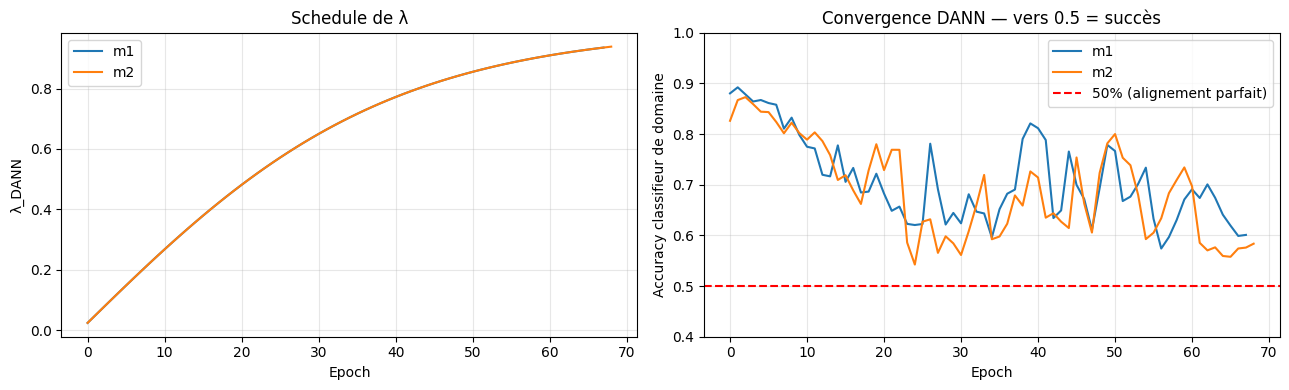

Accuracy domaine finale (moyenne ensemble) : 0.592
  → si proche de 0.50 : DANN a aligné les distributions
  → si proche de 1.00 : DANN n'a pas réussi (λ trop faible ou modèle trop puissant)


In [ ]:
# Si DANN fonctionne, l'accuracy du classifieur de domaine doit converger vers ~50%
# (= il ne peut plus distinguer photo de spec dans l'espace des features)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for j, (lam_log, acc_dom) in enumerate(historique_dann):
    axes[0].plot(lam_log, label=f'm{j+1}')
    axes[1].plot(acc_dom, label=f'm{j+1}')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('λ_DANN')
axes[0].set_title('Schedule de λ'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(0.5, color='red', ls='--', label='50% (alignement parfait)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy classifieur de domaine')
axes[1].set_title('Convergence DANN — vers 0.5 = succès')
axes[1].set_ylim(0.4, 1.0); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig("dann_diagnostic.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"Accuracy domaine finale (moyenne ensemble) : {np.mean([a[-1] for _, a in historique_dann]):.3f}")
print("  → si proche de 0.50 : DANN a aligné les distributions")
print("  → si proche de 1.00 : DANN n'a pas réussi (λ trop faible ou modèle trop puissant)")

## 15. Figure de synthèse

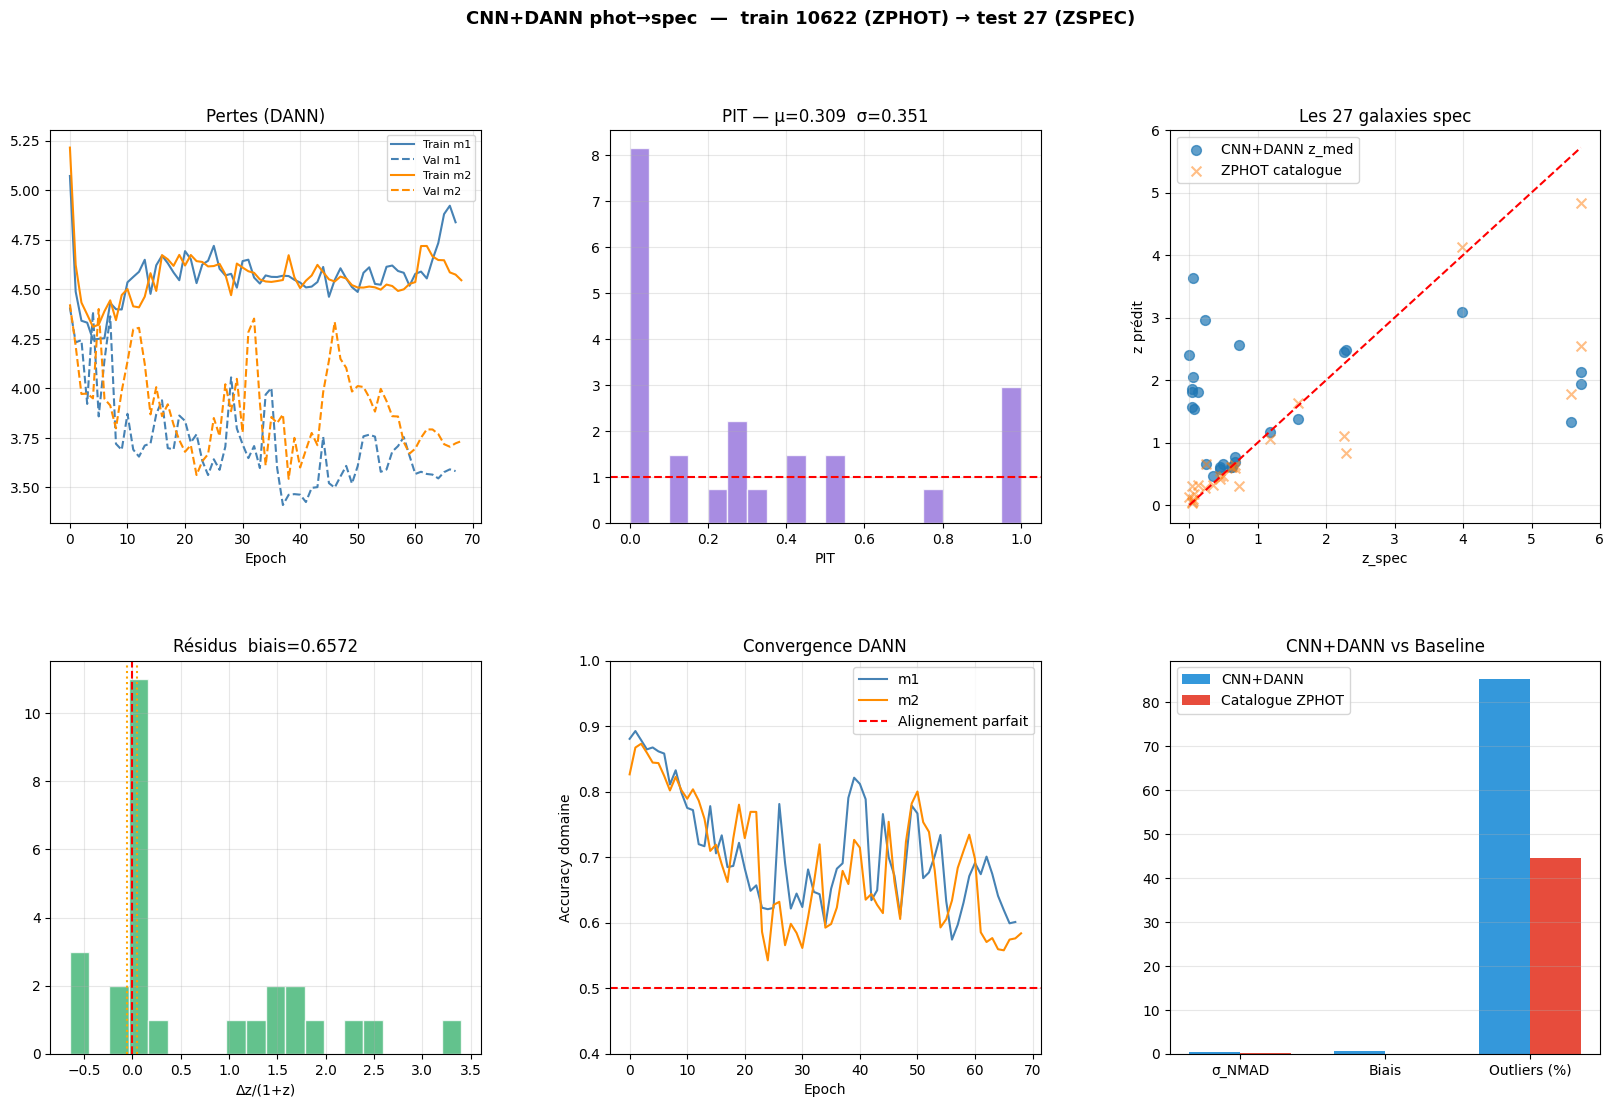

In [ ]:
fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)
couleurs = ['steelblue', 'darkorange']

ax = fig.add_subplot(gs[0, 0])
for j, (pt, pv, _, _) in enumerate(historique):
    ax.plot(pt, color=couleurs[j], label=f'Train m{j+1}')
    ax.plot(pv, color=couleurs[j], ls='--', label=f'Val m{j+1}')
ax.set_title("Pertes (DANN)"); ax.set_xlabel("Epoch"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 1])
ax.hist(valeurs_pit, bins=20, range=(0,1), density=True, color='mediumpurple', alpha=0.8, edgecolor='white')
ax.axhline(1.0, color='red', ls='--')
ax.set_title(f"PIT — μ={valeurs_pit.mean():.3f}  σ={valeurs_pit.std():.3f}")
ax.set_xlabel("PIT"); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[0, 2])
ax.scatter(yo_test, z_med, s=50, alpha=0.7, label='CNN+DANN z_med')
if m_baseline is not None:
    ax.scatter(yo_test, df_spec['ZPHOT'].values, s=50, alpha=0.5, marker='x', label='ZPHOT catalogue')
mx = max(yo_test.max(), z_med.max())
ax.plot([0, mx], [0, mx], 'r--', lw=1.5)
ax.set_xlabel("z_spec"); ax.set_ylabel("z prédit")
ax.set_title(f"Les {len(yo_test)} galaxies spec")
ax.legend(); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 0])
ax.hist(m_med['dz'], bins=20, color='mediumseagreen', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', ls='--')
ax.axvline(-0.05, color='orange', ls=':'); ax.axvline(0.05, color='orange', ls=':')
ax.set_title(f"Résidus  biais={m_med['biais']:.4f}")
ax.set_xlabel("Δz/(1+z)"); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 1])
for j, (_, acc_dom) in enumerate(historique_dann):
    ax.plot(acc_dom, color=couleurs[j], label=f'm{j+1}')
ax.axhline(0.5, color='red', ls='--', label='Alignement parfait')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy domaine')
ax.set_title('Convergence DANN')
ax.set_ylim(0.4, 1.0); ax.legend(); ax.grid(alpha=0.3)

ax = fig.add_subplot(gs[1, 2])
labels_metr = ['σ_NMAD', 'Biais', 'Outliers (%)']
if m_baseline is not None:
    vals_cnn  = [m_med['sigma'], abs(m_med['biais']), m_med['outliers']]
    vals_base = [m_baseline['sigma'], abs(m_baseline['biais']), m_baseline['outliers']]
    x = np.arange(len(labels_metr)); w = 0.35
    ax.bar(x - w/2, vals_cnn,  w, label='CNN+DANN', color='#3498db')
    ax.bar(x + w/2, vals_base, w, label='Catalogue ZPHOT', color='#e74c3c')
    ax.set_xticks(x); ax.set_xticklabels(labels_metr); ax.legend()
    ax.set_title('CNN+DANN vs Baseline')
ax.grid(axis='y', alpha=0.3)

plt.suptitle(f"CNN+DANN phot→spec  —  train {len(t_yo_train)} (ZPHOT) → test {len(yo_test)} (ZSPEC)",
             fontsize=13, fontweight='bold')
plt.savefig("cnn_dann_phot2spec.png", dpi=120, bbox_inches='tight')
plt.show()

## 16. Comment lire les résultats

| Signe | Interprétation |
|---|---|
| **Accuracy domaine ≈ 0.50** | DANN a réussi : features invariantes au domaine |
| **Accuracy domaine ≈ 1.00** | DANN n'a pas convergé : essayer λ plus fort ou plus d'epochs |
| **σ_NMAD baisse vs sans DANN** | L'alignement a amélioré la généralisation |
| **σ_NMAD stable, biais baisse** | DANN a corrigé un offset systématique sans toucher la dispersion |
| **σ_NMAD monte** | Le DANN a dégradé la tâche redshift — λ_DOM_MAX trop fort |

### Si les résultats sont décevants

1. Augmenter `LAMBDA_DOM_MAX` (1.0 → 2.0 ou 3.0) — pousse plus l'alignement
2. Augmenter `patience` à 50, `nb_epochs` à 300 — DANN converge lentement
3. Réduire `prob_masque` à 0.10 — moins d'augmentation, plus de signal de domaine
4. Essayer sans random masking — pour isoler l'effet du DANN seul

### Limitations honnêtes (à mettre dans le rapport)

- Protocole transductif : les features de test sont vues à l'entraînement (sans labels)
- N=27 cible : le DANN avec si peu de samples cibles est statistiquement fragile
- Le σ_NMAD reste impacté par la difficulté intrinsèque de l'échantillon spec
